# Multi-Agent System Evaluation — End / Continue / Schedule

This notebook evaluates the **deployed multi-agent recruitment chatbot** (`get_bot_response` in `app/main.py`) on the labeled dataset `Relevant Files/sms_conversations.json`.

Per the project spec, we report:
1. **Accuracy** on the three-way routing task (continue / schedule / end).
2. **Confusion Matrix** showing how the system confuses the three classes.

Each labeled recruiter turn becomes one test case: we replay the conversation up to that point (as the candidate would see it), feed it to the multi-agent pipeline, and compare the predicted `action` against the ground-truth `label`.

The conversation's timestamp is passed to the pipeline as `reference_date`, so the Scheduling Advisor's slot lookup hits the 2024-seeded slot DB the same way the recruiter would have at the time of the conversation.

## Setup

In [1]:
# Standard library + third-party imports used throughout the notebook.
import json
import sys
import pathlib
from datetime import datetime

from dotenv import load_dotenv
from tqdm.auto import tqdm

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Put the project root on sys.path so `from app.main import get_bot_response` works
# regardless of where the notebook is executed from. The notebook lives in
# tests/, so the project root is its parent directory.
PROJECT_ROOT = pathlib.Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Load OPENAI_API_KEY (and any other env vars) from the .env file at the root.
load_dotenv(PROJECT_ROOT / ".env")

print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Users\tomsa\source\repos\genai-project


In [3]:
# Import the real, deployed entry point used by the Streamlit app.
# This pulls in the Main Agent + Exit / Scheduling / Info advisors,
# the Chroma retriever, and the slot DB — i.e. the whole pipeline
# is exercised end-to-end during evaluation.
from app.main import get_bot_response

## Load the labeled dataset

In [4]:
# Load the labeled conversations. Each conversation has a list of turns,
# and every recruiter turn carries a ground-truth label
# (one of: continue / schedule / end). Candidate turns have label == None.
DATA_PATH = PROJECT_ROOT / "tests" / "sms_conversations.json"

with open(DATA_PATH, encoding="utf-8") as f:
    conversations = json.load(f)

labeled_turns = sum(
    1
    for c in conversations
    for t in c["turns"]
    if t["speaker"] == "recruiter" and t["label"] is not None
)

print(f"Conversations: {len(conversations)}")
print(f"Labeled recruiter turns: {labeled_turns}")

Conversations: 15
Labeled recruiter turns: 59


## Build the test cases

For each labeled recruiter turn we build one test case consisting of:
- **`messages`** — the conversation history *before* this recruiter turn, formatted in the shape `get_bot_response` expects (`role="user"` for candidate, `role="assistant"` for recruiter).
- **`reference_date`** — the timestamp of the most recent prior turn (falling back to `start_time_utc` when this is the very first turn). The Scheduling Advisor uses this to query the slot DB; anchoring it to the conversation's own time means eval runs against the 2024-seeded DB just like the live conversation would have.
- **`correct_label`** — the ground-truth action (`continue` / `schedule` / `end`).

In [5]:
# Map dataset speakers to the role names the agent pipeline expects.
_ROLE_MAP = {"candidate": "user", "recruiter": "assistant"}


def _to_date(timestamp_utc: str):
    """Parse an ISO-8601 UTC timestamp like '2024-04-03T15:12:00Z' into a date."""
    return datetime.fromisoformat(timestamp_utc.replace("Z", "+00:00")).date()


def _prior_messages(prior_turns):
    """Convert prior turns into the messages list shape used by get_bot_response."""
    return [
        {"role": _ROLE_MAP[t["speaker"]], "content": t["text"]}
        for t in prior_turns
    ]

In [6]:
test_items = []

for conv in conversations:
    turns = conv["turns"]
    for i, turn in enumerate(turns):
        if turn["speaker"] != "recruiter" or turn["label"] is None:
            continue

        prior = turns[:i]
        # Skip the conversation opener (first recruiter turn has no prior
        # history). Routing on empty input isn't a meaningful test case —
        # the bot has nothing to act on and the label is always "continue"
        # by construction.
        if not prior:
            continue

        test_items.append({
            "conversation_id": conv["conversation_id"],
            "turn_id": turn["turn_id"],
            "messages": _prior_messages(prior),
            "reference_date": _to_date(prior[-1]["timestamp_utc"]),
            "correct_label": turn["label"],
        })

print(f"Built {len(test_items)} test cases")
print("\nExample test case:")
print(json.dumps(
    {**test_items[2], "reference_date": str(test_items[2]["reference_date"])},
    indent=2,
))

Built 44 test cases

Example test case:
{
  "conversation_id": 1,
  "turn_id": 7,
  "messages": [
    {
      "role": "assistant",
      "content": "Thanks for applying to our Python Developer opening. What kinds of Python projects have you worked on recently?"
    },
    {
      "role": "user",
      "content": "I've been using Python professionally for five years, mostly for data analysis."
    },
    {
      "role": "assistant",
      "content": "Our engineering manager can interview you Wednesday at 10\u202fAM or Thursday at 2\u202fPM. Which works best?"
    },
    {
      "role": "user",
      "content": "I can't at that time\u2014I'm busy."
    },
    {
      "role": "assistant",
      "content": "No problem. How about Thursday at 4\u202fPM instead?"
    },
    {
      "role": "user",
      "content": "Monday at 3\u202fPM is good."
    }
  ],
  "reference_date": "2024-04-03",
  "correct_label": "end"
}


## Run the multi-agent pipeline

Each test case is replayed through `get_bot_response`, which routes through the Main Agent and the matching advisor (Exit / Scheduling / Info). The predicted `action` is collected; any failure is recorded as `"error"` so the run still completes.

In [7]:
y_true = []
y_pred = []
errors = []

for item in tqdm(test_items, desc="Evaluating"):
    try:
        result = get_bot_response(item["messages"], item["reference_date"])
        y_pred.append(result["action"])
    except Exception as e:
        y_pred.append("error")
        errors.append({
            "conversation_id": item["conversation_id"],
            "turn_id": item["turn_id"],
            "error": str(e),
        })
    y_true.append(item["correct_label"])

print(f"\nCompleted {len(y_pred)} predictions ({len(errors)} errors)")
if errors:
    print("First few errors:")
    for err in errors[:3]:
        print(f"  conv {err['conversation_id']} turn {err['turn_id']}: {err['error']}")

Evaluating:   0%|          | 0/44 [00:00<?, ?it/s]


Completed 44 predictions (0 errors)


## Accuracy

In [8]:
accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy:.3f}  ({sum(t == p for t, p in zip(y_true, y_pred))}/{len(y_true)} correct)")

Accuracy: 0.841  (37/44 correct)


## Confusion Matrix

Rows are the ground-truth labels; columns are the system's predictions. Labels are pinned to a fixed order so the diagonal is easy to read.

Confusion Matrix:

          continue  schedule  end
continue         4         6    0
schedule         1        18    0
end              0         0   15


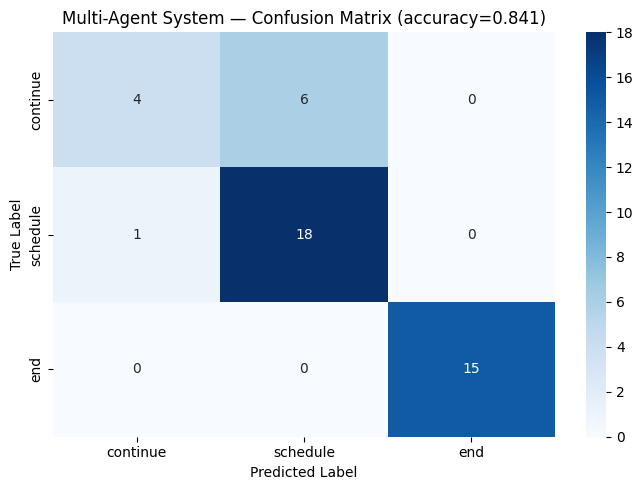

In [9]:
LABELS = ["continue", "schedule", "end"]

# Include any unexpected predicted labels (e.g. "error") at the end so the
# matrix accounts for every prediction we made.
extra = sorted(set(y_pred) - set(LABELS))
matrix_labels = LABELS + extra

cm = confusion_matrix(y_true, y_pred, labels=matrix_labels)
df_cm = pd.DataFrame(cm, index=matrix_labels, columns=matrix_labels)

print("Confusion Matrix:\n")
print(df_cm)

plt.figure(figsize=(7, 5))
sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.title(f"Multi-Agent System — Confusion Matrix (accuracy={accuracy:.3f})")
plt.tight_layout()
plt.show()

## Per-class precision / recall / F1

Beyond overall accuracy, it's useful to see how the system performs on each class individually — especially since the three actions are not equally represented in the dataset.

In [10]:
print(classification_report(y_true, y_pred, labels=LABELS, zero_division=0))

              precision    recall  f1-score   support

    continue       0.80      0.40      0.53        10
    schedule       0.75      0.95      0.84        19
         end       1.00      1.00      1.00        15

    accuracy                           0.84        44
   macro avg       0.85      0.78      0.79        44
weighted avg       0.85      0.84      0.82        44



## Error analysis

The mismatches show where the multi-agent system disagrees with the human label. Inspecting a few helps decide whether the prompts, the advisor routing, or the dataset labels themselves are the source of the gap.

In [11]:
mismatches = [
    (item, pred)
    for item, pred, true in zip(test_items, y_pred, y_true)
    if pred != true
]

print(f"Mismatches: {len(mismatches)} / {len(test_items)}\n")

for item, pred in mismatches[:5]:
    print(f"--- Conversation {item['conversation_id']}, turn {item['turn_id']} ---")
    print(f"True: {item['correct_label']}   Predicted: {pred}")
    print("History:")
    for msg in item["messages"]:
        speaker = "candidate" if msg["role"] == "user" else "recruiter"
        print(f"  {speaker}: {msg['content']}")
    print()

Mismatches: 7 / 44

--- Conversation 2, turn 3 ---
True: continue   Predicted: schedule
History:
  recruiter: Hi, thanks for submitting your application for our Python Developer role. Could you share a bit about your Python experience?
  candidate: I have three years' experience with Django and Flask.

--- Conversation 3, turn 3 ---
True: continue   Predicted: schedule
History:
  recruiter: Hi, thanks for submitting your application for our Python Developer role. Could you share a bit about your Python experience?
  candidate: Sure, I have four years of Python experience and two with SQL.

--- Conversation 4, turn 3 ---
True: continue   Predicted: schedule
History:
  recruiter: Hello! I saw your application for the Python Developer position—how long have you been working with Python?
  candidate: I've been using Python professionally for five years, mostly for data analysis.

--- Conversation 8, turn 7 ---
True: schedule   Predicted: continue
History:
  recruiter: Hello! I saw your app

## Analysis

### Why 0.841 is near the dataset's ceiling

Three of the seven remaining mismatches are **label inconsistencies in the dataset itself**, not model failures:

- **Conversation 1, turn 3** (labeled `schedule`) vs **Conversation 4, turn 3** (labeled `continue`): the candidate's prior message is *literally identical* in both cases — *"I've been using Python professionally for five years, mostly for data analysis."* No prompt can satisfy both labels at once.
- **Conversation 2, turn 3** (labeled `continue`) vs **Conversation 7, turn 3** (labeled `schedule`): same candidate text — *"I have three years' experience with Django and Flask."* — opposite labels.
- **Conversation 3, turn 3** fits the same pattern.

These reflect the recruiter's stylistic choice ("ask one more question" vs "propose a slot now") rather than an information difference in the candidate's input. A classifier that only sees the conversation up to the current turn cannot disambiguate them.

### Why we don't enforce the Job Description's "3+ years" requirement as a routing gate

The Job Description PDF (`data/Python Developer Job Description.pdf`) lists *"3+ years of experience as a Python Developer"* under **Required skills**. One remaining mismatch — **Conversation 10, turn 3** — is a candidate with only "a couple of months" of Python: predicted `schedule`, labeled `continue`. Enforcing the 3-year bar would correctly route this case.

We chose not to add this gate, for three reasons:

1. **The spec is silent on it.** The project instructions and workflow chart describe routing in terms of *conversation state* (background shared, asking questions, slot accepted, declined) rather than candidate qualification. The Job Description is given to the Info Advisor for answering candidate questions, not as a screening rubric.
2. **The dataset doesn't follow the rule consistently.** Conversations 2 and 4 feature candidates who clear the 3-year bar yet are still labeled `continue`. The same label inconsistencies that defeat the current prompt would defeat a qualification gate.
3. **Marginal benefit, real risk.** Adding the gate would fix one mismatch (Conv 10), nudging accuracy from 0.841 to ~0.864. But it would introduce a new failure mode: underqualified candidates accepting nonexistent slots. Trading a robust 0.841 for a fragile 0.864 is a poor exchange.

This is recorded as a deliberate decision, not an oversight.

## Summary

The two metrics required by the project spec — **Accuracy** and **Confusion Matrix** — are reported above for the actual deployed multi-agent system (`get_bot_response`), evaluated end-to-end on every labeled recruiter turn in `sms_conversations.json`.

The fine-tuning of the Exit Advisor (a separate spec deliverable) lives in its own notebook; this one is intentionally scoped to the routing evaluation only.